In [73]:

#Import Libraries

import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import plotly.express as px


In [74]:
#Website Test

url = "https://books.toscrape.com/"

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [75]:
#Parse HTML

soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [76]:
#First Book

book = soup.find("article", class_="product_pod")

title = book.h3.a["title"]
price = book.find("p", class_="price_color").text
rating = book.find("p")["class"][1]
availability = book.find("p", class_="instock availability").text.strip()

print("Title :", title)
print("Price :", price)
print("Rating :", rating)
print("Availability :", availability)

Title : A Light in the Attic
Price : Â£51.77
Rating : Three
Availability : In stock


In [77]:
#Scrape All 20 Books

books = []

for book in soup.find_all("article", class_="product_pod"):

    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p")["class"][1]
    availability = book.find("p", class_="instock availability").text.strip()

    books.append([title, price, rating, availability])

In [78]:
#Create DataFrame

df = pd.DataFrame(
    books,
    columns=["Title", "Price", "Rating", "Availability"]
)

df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [79]:
#Save CSV

df.to_csv("books.csv", index=False)

print("CSV Saved Successfully")

CSV Saved Successfully


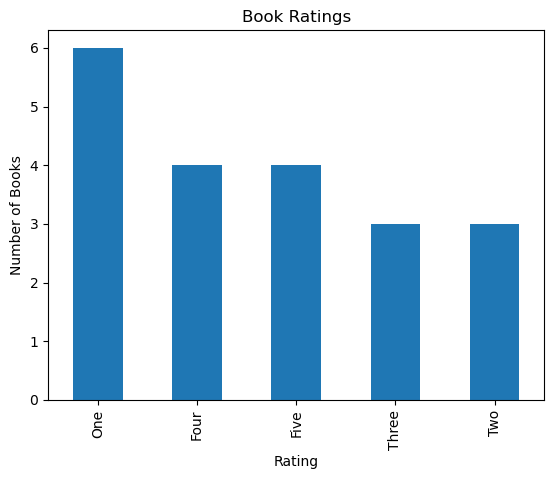

In [80]:
#Rating Chart

rating_count = df["Rating"].value_counts()

rating_count.plot(kind="bar")

plt.title("Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

In [81]:
#Price Cleaning
df["Price"] = df["Price"].str.extract(r'(\d+\.\d+)').astype(float)

In [82]:
df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [83]:
df.shape

(20, 4)

In [84]:
df.tail()

,Title,Price,Rating,Availability
15,Our Band Could Be Your Life: Scenes from the A...,57.25,Three,In stock
16,Olio,23.88,One,In stock
17,Mesaerion: The Best Science Fiction Stories 18...,37.59,One,In stock
18,Libertarianism for Beginners,51.33,Two,In stock
19,It's Only the Himalayas,45.17,Two,In stock


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         20 non-null     object 
 1   Price         20 non-null     float64
 2   Rating        20 non-null     object 
 3   Availability  20 non-null     object 
dtypes: float64(1), object(3)
memory usage: 772.0+ bytes


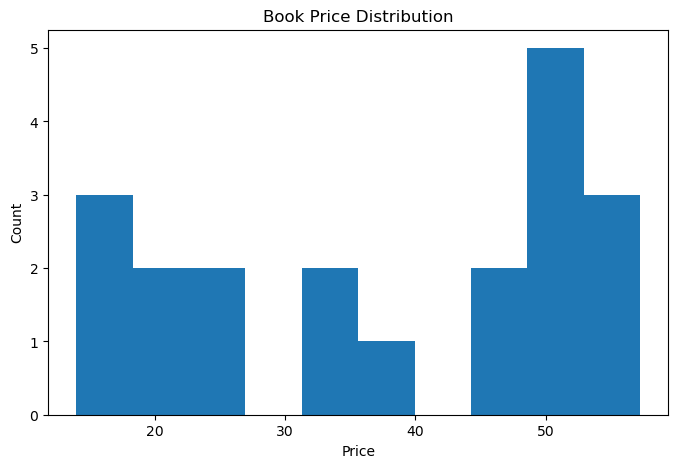

In [86]:
#Price Distribution

plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=10)

plt.title("Book Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [87]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm.notebook import tqdm
import logging
import time

In [88]:
logging.basicConfig(
    filename="book_scraper.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [89]:
books = []

In [30]:
base_url = "https://books.toscrape.com/catalogue/page-{}.html"

for page in tqdm(range(1,51)):

    try:

        url = base_url.format(page)

        response = requests.get(url, timeout=10)

        soup = BeautifulSoup(response.text,"html.parser")

        all_books = soup.find_all("article",class_="product_pod")

        for book in all_books:

            title = book.h3.a["title"]

            price = book.find("p",class_="price_color").text

            rating = book.find("p")["class"][1]

            availability = book.find(
                "p",
                class_="instock availability"
            ).text.strip()

            books.append([
                title,
                price,
                rating,
                availability
            ])

        logging.info(f"Page {page} Scraped")

        time.sleep(0.5)

    except Exception as e:

        logging.error(f"Page {page} Error : {e}")

  0%|          | 0/50 [00:00<?, ?it/s]

In [90]:
df = pd.DataFrame(
    books,
    columns=[
        "Title",
        "Price",
        "Rating",
        "Availability"
    ]
)

df.head()

,Title,Price,Rating,Availability


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         20 non-null     object
 1   Price         20 non-null     object
 2   Rating        20 non-null     object
 3   Availability  20 non-null     object
dtypes: object(4)
memory usage: 772.0+ bytes


In [66]:
df.tail()

,Title,Price,Rating,Availability
15,Our Band Could Be Your Life: Scenes from the A...,Â£57.25,Three,In stock
16,Olio,Â£23.88,One,In stock
17,Mesaerion: The Best Science Fiction Stories 18...,Â£37.59,One,In stock
18,Libertarianism for Beginners,Â£51.33,Two,In stock
19,It's Only the Himalayas,Â£45.17,Two,In stock


In [91]:
df.shape

(0, 4)

In [92]:
df.to_csv("books.csv",index=False)

df.to_excel("books.xlsx",index=False)

print("Saved Successfully")

Saved Successfully


In [93]:
df["Price"].head(10)

Series([], Name: Price, dtype: object)

In [68]:

df["Price"] = (
    df["Price"]
      .str.extract(r'(\d+\.\d+)')[0]
      .astype(float)
)

In [94]:
df.head()

,Title,Price,Rating,Availability


In [42]:
print(df.shape[0])

1980


In [43]:
print(df["Price"].mean())

35.064181818181815


In [99]:
df.sort_values("Price",ascending=False).head()

,Title,Price,Rating,Availability


In [100]:

df["Rating"].value_counts()


Series([], Name: count, dtype: int64)

IndexError: index 0 is out of bounds for axis 0 with size 0

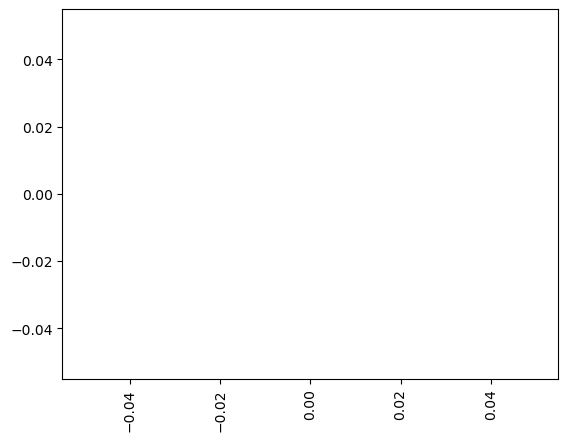

In [98]:
import matplotlib.pyplot as plt

df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Book Ratings")
plt.xlabel("Stars")
plt.ylabel("Books")

plt.show()

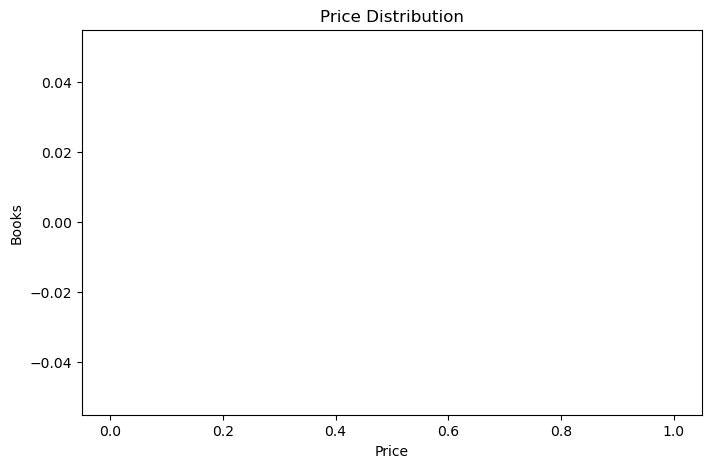

In [101]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"],bins=20)

plt.xlabel("Price")
plt.ylabel("Books")

plt.title("Price Distribution")

plt.show()

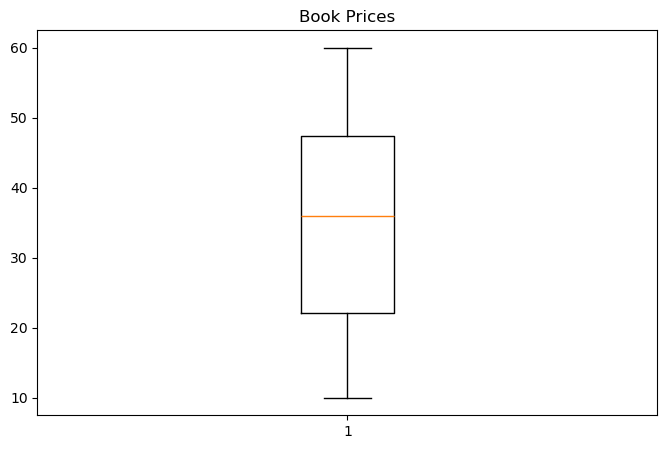

In [48]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Price"])

plt.title("Book Prices")

plt.show()

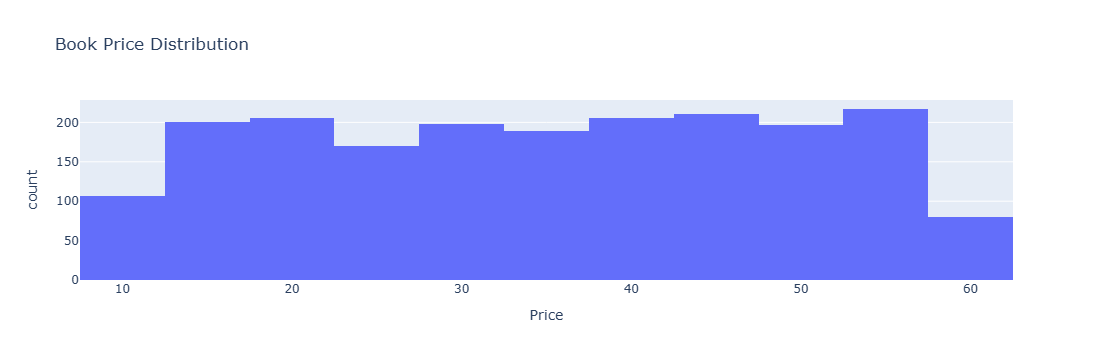

In [49]:
import plotly.express as px

fig = px.histogram(
    df,
    x="Price",
    nbins=20,
    title="Book Price Distribution"
)

fig.show()